/tmp/ipykernel_1894/860566476.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2019-01-01", end="2020-01-01")
[*********************100%***********************]  1 of 1 completed


Données téléchargées : 252 lignes.
Price           Close       High        Low       Open     Volume
Date                                                             
2019-01-02  37.503738  37.724602  36.627416  36.784157  148158800
2019-01-03  33.768074  34.606398  33.722951  34.193172  365248800
2019-01-04  35.209610  35.278483  34.150426  34.323790  234428400
2019-01-07  35.131248  35.344988  34.649153  35.314113  219111200
2019-01-08  35.800961  36.055072  35.271369  35.518352  164101200

--- Résultats du Modèle ---
Erreur Quadratique Moyenne (MSE) : 0.64
Coefficient de détermination (R²) : 0.9914
Coeficients du modèle : [ 4.48589057e-02  4.56353720e-01  5.08039703e-01 -5.40079648e-11]
Ordonnée à l'origine : -0.24629366073475012


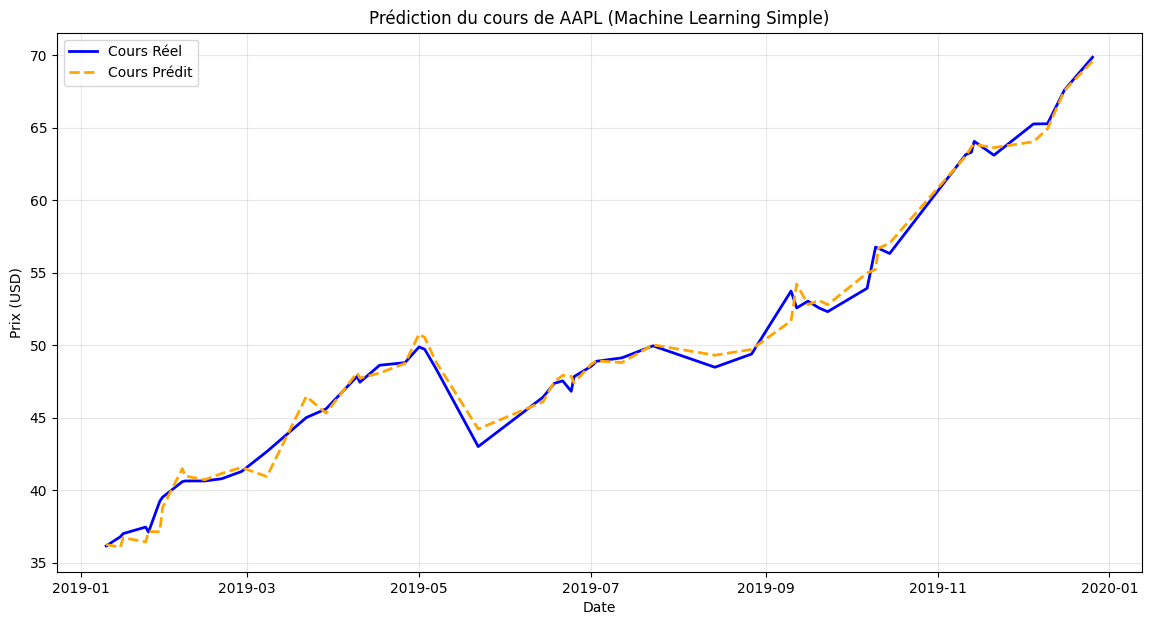

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. TÉLÉCHARGEMENT DES DONNÉES
# ---------------------------------------------------------
# On télécharge les données historiques de l'action Apple (AAPL)
# Période : 1er Janvier 2020 au 1er Janvier 2023
ticker = "AAPL"
data = yf.download(ticker, start="2019-01-01", end="2020-01-01")

# Gestion des colonnes (yfinance renvoie parfois un MultiIndex)
# Si les colonnes sont un tuple ('Close', 'AAPL'), on les aplatit
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(1)

# Vérification des données manquantes
data.dropna(inplace=True)

print(f"Données téléchargées : {len(data)} lignes.")
print(data.head())

# ---------------------------------------------------------
# 2. PRÉPARATION DES DONNÉES (FEATURE ENGINEERING)
# ---------------------------------------------------------
# On crée notre variable cible (Target) : le cours de clôture du JOUR SUIVANT
# On décale la colonne 'Close' de -1 vers le haut
data['Target'] = data['Close'].shift(-1)

# On supprime la dernière ligne car elle n'a pas de cible (futur inconnu)
data = data[:-1]

# Sélection des caractéristiques (Features) pour l'entraînement
# On utilise : Ouverture, Plus haut, Plus bas, Volume
features = ['Open', 'High', 'Low', 'Volume']
X = data[features]
y = data['Target']


# ---------------------------------------------------------
# 3. SÉPARATION ENTRAINEMENT / TEST
# ---------------------------------------------------------
# On sépare les données : 80% pour entraîner, 20% pour tester
# random_state=42 assure la reproductibilité du résultat
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------------------------------------------------
# 4. ENTRAÎNEMENT DU MODÈLE
# ---------------------------------------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# ---------------------------------------------------------
# 5. PRÉDICTION ET ÉVALUATION
# ---------------------------------------------------------
# On fait des prédictions sur l'ensemble de test
predictions = model.predict(X_test)

# Calcul des métriques de performance
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("\n--- Résultats du Modèle ---")
print(f"Erreur Quadratique Moyenne (MSE) : {mse:.2f}")
print(f"Coefficient de détermination (R²) : {r2:.4f}")
print(f"Coeficients du modèle : {model.coef_}")
print(f"Ordonnée à l'origine : {model.intercept_}")

# ---------------------------------------------------------
# 6. VISUALISATION (GRAPHIQUE)
# ---------------------------------------------------------
# Pour le graphique, on aligne les index de temps
# On crée un DataFrame pour comparer facilement
results_df = pd.DataFrame({'Date': X_test.index, 'Réel': y_test, 'Prédit': predictions})
results_df.sort_index(inplace=True)

plt.figure(figsize=(14, 7))
plt.plot(results_df['Date'], results_df['Réel'], label='Cours Réel', color='blue', linewidth=2)
plt.plot(results_df['Date'], results_df['Prédit'], label='Cours Prédit', color='orange', linestyle='--', linewidth=2)

plt.title(f'Prédiction du cours de {ticker} (Machine Learning Simple)')
plt.xlabel('Date')
plt.ylabel('Prix (USD)')
plt.legend()
plt.grid(True, alpha=0.3)

# Sauvegarde optionnelle du graphique
# plt.savefig('prediction_aapl.png')

plt.show()

/tmp/ipykernel_1894/2071196310.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("BZ=F", start="2020-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


             ds       yhat
1511 2026-01-01  59.374711
1512 2026-01-02  59.791761
1513 2026-01-03  62.126084
1514 2026-01-04  62.368321
1515 2026-01-05  60.435815
1516 2026-01-06  60.617755
1517 2026-01-07  60.768077


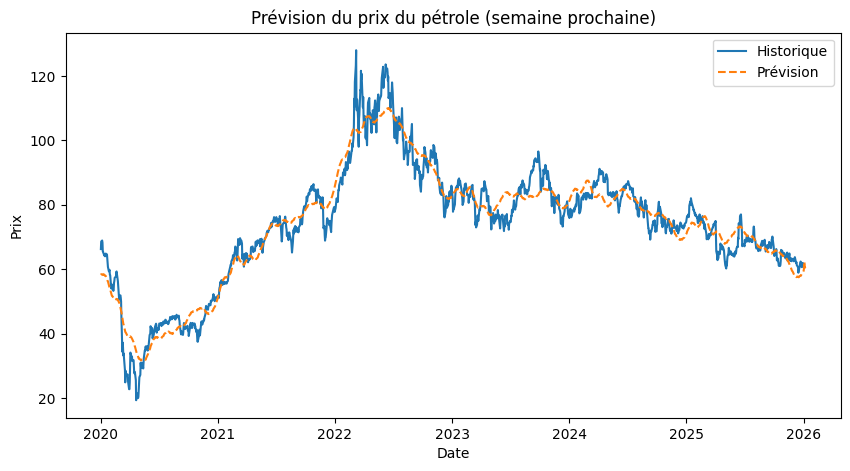

In [4]:
# Installer les bibliothèques nécessaires
!pip install yfinance prophet

# Importer les librairies
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

# Télécharger les données du pétrole (Brent Crude Oil)
data = yf.download("BZ=F", start="2020-01-01", end="2026-01-01")

# Préparer les données pour Prophet
df = data.reset_index()[['Date', 'Close']]
df.columns = ['ds', 'y']

# Créer et entraîner le modèle
model = Prophet()
model.fit(df)

# Créer un dataframe pour les 7 prochains jours
future = model.make_future_dataframe(periods=7)

# Faire la prédiction
forecast = model.predict(future)

# Afficher les prévisions
print(forecast[['ds', 'yhat']].tail(7))

# Tracer la courbe
plt.figure(figsize=(10,5))
plt.plot(df['ds'], df['y'], label='Historique')
plt.plot(forecast['ds'], forecast['yhat'], label='Prévision', linestyle='dashed')
plt.legend()
plt.title("Prévision du prix du pétrole (semaine prochaine)")
plt.xlabel("Date")
plt.ylabel("Prix")
plt.show()

/tmp/ipykernel_1894/571832967.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("BZ=F", start="2022-01-01")
[*********************100%***********************]  1 of 1 completed
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


             ds       yhat
1069 2026-04-01  82.117575
1070 2026-04-02  82.111641
1071 2026-04-03  82.169659
1072 2026-04-04  74.383654
1073 2026-04-05  74.226822
1074 2026-04-06  81.530304
1075 2026-04-07  81.274376


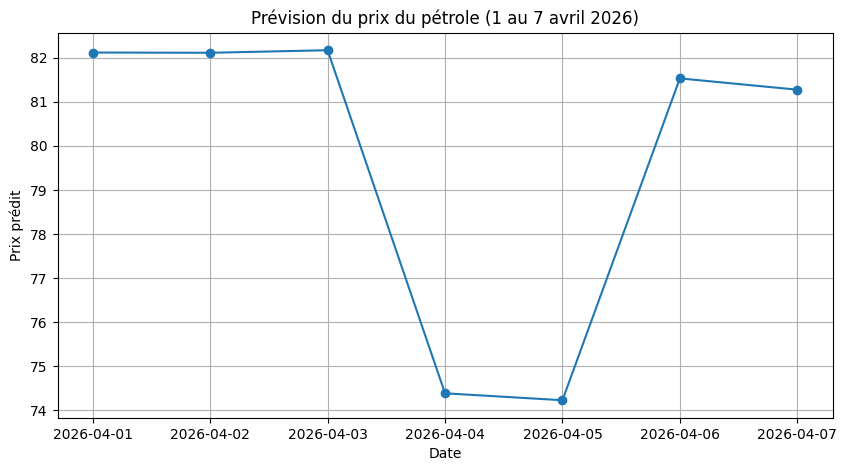

In [5]:
# Installer les bibliothèques
!pip install yfinance prophet

# Importer
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

# Télécharger les données historiques du pétrole (Brent)
data = yf.download("BZ=F", start="2022-01-01")

# Préparer les données pour Prophet
df = data.reset_index()[['Date', 'Close']]
df.columns = ['ds', 'y']

# Créer et entraîner le modèle
model = Prophet()
model.fit(df)

# Créer les dates futures jusqu'au 7 avril 2026
future = model.make_future_dataframe(periods=30)

# Prédictions
forecast = model.predict(future)

# Filtrer uniquement du 1 au 7 avril 2026
forecast_april = forecast[
    (forecast['ds'] >= '2026-04-01') &
    (forecast['ds'] <= '2026-04-07')
]

# Afficher les résultats
print(forecast_april[['ds', 'yhat']])

# Tracer uniquement cette période
plt.figure(figsize=(10,5))
plt.plot(forecast_april['ds'], forecast_april['yhat'], marker='o')
plt.title("Prévision du prix du pétrole (1 au 7 avril 2026)")
plt.xlabel("Date")
plt.ylabel("Prix prédit")
plt.grid()
plt.show()